# Tensors and Linear Algebra

            ## 1. Learning objectives

            - Distinguish scalars, vectors, matrices, and tensors
- Apply dot products, broadcasting, and matrix multiplication
- Use autograd on a computation graph

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Represent batches and model parameters in arrays whose shapes make operations precise.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            A tensor is a numbered box with any number of axes; matrix multiplication connects input features to output features.

## 6. Mathematical foundation

            $$C_{ij}=\sum_{k=1}^{p}A_{ik}B_{kj}.$$

            **Every symbol:**

            - $A$ has shape $n\times p$.
- $B$ has shape $p\times m$.
- $C$ has shape $n\times m$.
- $k$ indexes the shared dimension.

            **Why the equation is needed:** Every neural layer relies on compatible inner dimensions to combine features and weights.

            **Small numerical example:** For row [1,2] and column [2,-1], the dot product is 1(2)+2(-1)=0.

            **Connection to Python:** A @ B performs matrix multiplication; * performs elementwise multiplication.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
scalar = np.array(3.0)
vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([[1.0, 2.0], [3.0, 4.0]])
tensor = np.arange(24).reshape(2, 3, 4)
product = matrix @ np.array([[2.0], [-1.0]])
print("Ranks/shapes:", scalar.ndim, vector.shape, matrix.shape, tensor.shape)
print("Matrix product:", product.ravel())

Ranks/shapes: 0 (3,) (2, 2) (2, 3, 4)
Matrix product: [0. 2.]


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

a: (2, 2) b: (2, 1) c: (2, 1)
Scalar loss: 2.0
Gradient shape: (2, 2)


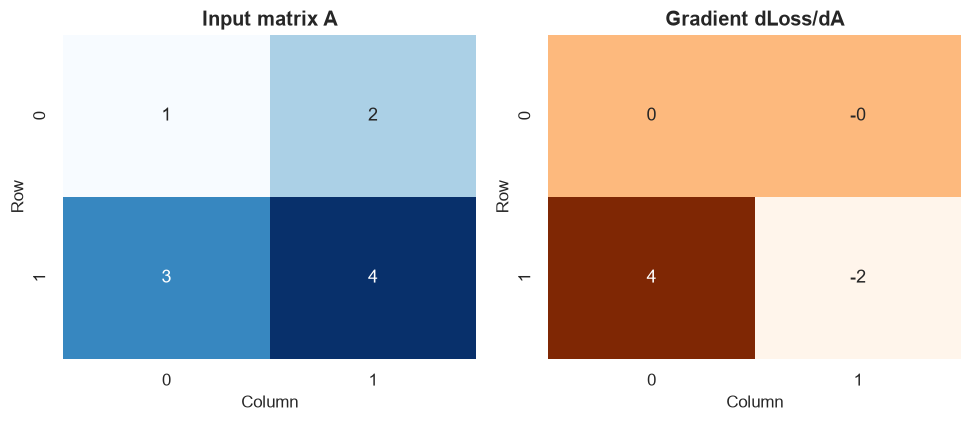

In [3]:
a = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)
b = torch.tensor([[2.], [-1.]])
c = a @ b
loss = (c ** 2).mean()
loss.backward()
print("a:", tuple(a.shape), "b:", tuple(b.shape), "c:", tuple(c.shape))
print("Scalar loss:", loss.item())
print("Gradient shape:", tuple(a.grad.shape))

figure, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.heatmap(a.detach().numpy(), annot=True, cmap="Blues", cbar=False, ax=axes[0])
axes[0].set(title="Input matrix A", xlabel="Column", ylabel="Row")
sns.heatmap(a.grad.numpy(), annot=True, cmap="Oranges", cbar=False, ax=axes[1])
axes[1].set(title="Gradient dLoss/dA", xlabel="Column", ylabel="Row")
figure.tight_layout()
plt.show()

**How to interpret the result:** The gradient has the same shape as the tensor it differentiates, so each input element receives a local sensitivity.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Batch size changes memory and gradient noise, even when the model architecture is unchanged.

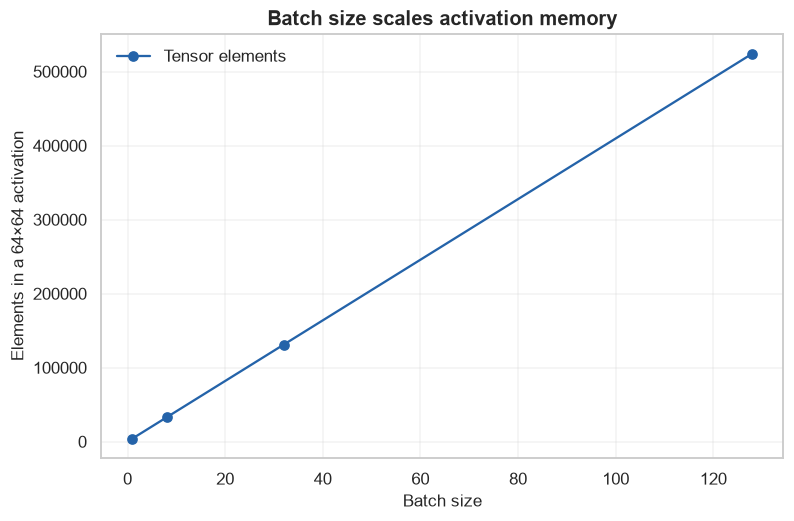

In [4]:
batch_sizes = np.array([1, 8, 32, 128])
elements = batch_sizes * 64 * 64
figure, axis = plt.subplots()
axis.plot(batch_sizes, elements, marker="o", color=COURSE_COLORS["blue"], label="Tensor elements")
axis.set(title="Batch size scales activation memory", xlabel="Batch size", ylabel="Elements in a 64×64 activation")
axis.legend()
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)